# YOLOE-26 Open-Vocabulary Detection and Segmentation with OpenVINO™

[YOLOE-26](https://docs.ultralytics.com/models/yoloe/) integrates the high-performance [YOLO26](https://docs.ultralytics.com/models/yolo26/) architecture with open-vocabulary capabilities, enabling real-time detection and segmentation of **any object class** using text prompts or a prompt-free mode for zero-shot inference.

Unlike traditional YOLO models limited to fixed categories, YOLOE-26 can detect and segment objects described by natural language — no retraining required. Key innovations include:

- **Re-parameterizable Region-Text Alignment (RepRTA)** — text-prompted detection with zero inference overhead after re-parameterization.
- **Lazy Region-Prompt Contrast (LRPC)** — prompt-free open-set recognition using 1200+ internal categories (LVIS + Objects365).
- **Built-in Instance Segmentation** — pixel-precise masks for all detected objects.
- **NMS-Free End-to-End Inference** — inherited from YOLO26 for simplified deployment.

This tutorial demonstrates two prompting modes with OpenVINO:
1. **Text Prompt** — detect user-specified classes via text descriptions.
2. **Prompt-Free** — zero-shot detection across 1200+ categories without any prompt.

We also show how to convert the models to OpenVINO IR and optimize with NNCF quantization.

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Text Prompt Detection and Segmentation](#Text-Prompt-Detection-and-Segmentation)
    - [Load YOLOE-26 Model](#Load-YOLOE-26-Model)
    - [Set Text Prompts and Run Inference](#Set-Text-Prompts-and-Run-Inference)
- [Prompt-Free Detection](#Prompt-Free-Detection)
- [Convert to OpenVINO IR](#Convert-to-OpenVINO-IR)
    - [Export Prompt-Free Model](#Export-Prompt-Free-Model)
    - [Select inference device](#Select-inference-device)
    - [Run OpenVINO Inference](#Run-OpenVINO-Inference)
    - [Run Prompt-Free OpenVINO Inference](#Run-Prompt-Free-OpenVINO-Inference)
- [Optimize with NNCF Quantization](#Optimize-with-NNCF-Quantization)
    - [Validate Quantized Model](#Validate-Quantized-Model)
- [Compare Performance](#Compare-Performance)
- [Interactive Demo](#Interactive-Demo)


### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/yolov26-optimization/yoloe-26-open-vocabulary.ipynb" />

## Prerequisites
[back to top ⬆️](#Table-of-contents:)

Install necessary packages.

In [ ]:
import platform

if platform.system() == "Darwin":
    %pip install -q "numpy<2.0.0"


%pip install -qU "openvino>=2026.0.0" "nncf>=3.0.0"
%pip install -q "torch==2.10" torchvision --extra-index-url https://download.pytorch.org/whl/cpu
%pip install -q "ultralytics==8.4.43" tqdm opencv-python Pillow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Import required utility functions.

In [2]:
from pathlib import Path
import requests

if not Path("notebook_utils.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
    )

    open("notebook_utils.py", "w").write(r.text)

from notebook_utils import download_file, VideoPlayer, device_widget, quantization_widget

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("yoloe-26-open-vocabulary.ipynb")

In [3]:
# Download test images
IMAGE_PATH = Path("./data/coco_bike.jpg")

if not IMAGE_PATH.exists():
    download_file(
        url="https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/image/coco_bike.jpg",
        filename=IMAGE_PATH.name,
        directory=IMAGE_PATH.parent,
    )

## Text Prompt Detection and Segmentation
[back to top ⬆️](#Table-of-contents:)

YOLOE-26 supports **text-prompted detection**: you specify the classes you want to detect using natural language, and the model finds them in the image — along with instance segmentation masks.

This is powered by the **Re-parameterizable Region-Text Alignment (RepRTA)** module, which aligns text embeddings (e.g., from CLIP) with visual features. After setting classes, RepRTA is folded into the model, ensuring **zero inference overhead**.

### Load YOLOE-26 Model
[back to top ⬆️](#Table-of-contents:)

YOLOE-26 models are available in all five YOLO26 sizes. All models perform instance segmentation by default.

Available text/visual prompt models: `yoloe-26n-seg`, `yoloe-26s-seg`, `yoloe-26m-seg`, `yoloe-26l-seg`, `yoloe-26x-seg`.

In [4]:
import ipywidgets as widgets

model_id = ["yoloe-26s-seg", "yoloe-26n-seg", "yoloe-26m-seg", "yoloe-26l-seg", "yoloe-26x-seg"]

model_name = widgets.Dropdown(options=model_id, value=model_id[0], description="Model")

model_name

Dropdown(description='Model', options=('yoloe-26s-seg', 'yoloe-26n-seg', 'yoloe-26m-seg', 'yoloe-26l-seg', 'yo…

In [5]:
from ultralytics import YOLOE

MODEL_NAME = model_name.value

model = YOLOE(f"{MODEL_NAME}.pt")

### Set Text Prompts and Run Inference
[back to top ⬆️](#Table-of-contents:)

Use `model.set_classes()` to specify the classes you want to detect. This only needs to be done once after loading the model. The model will detect and segment only the specified classes.


image 1/1 /home/maleksandr/test_notebooks/yolov26/openvino_notebooks/notebooks/yolov26-optimization/data/coco_bike.jpg: 480x640 2 cars, 1 dog, 110.8ms
Speed: 2.1ms preprocess, 110.8ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)


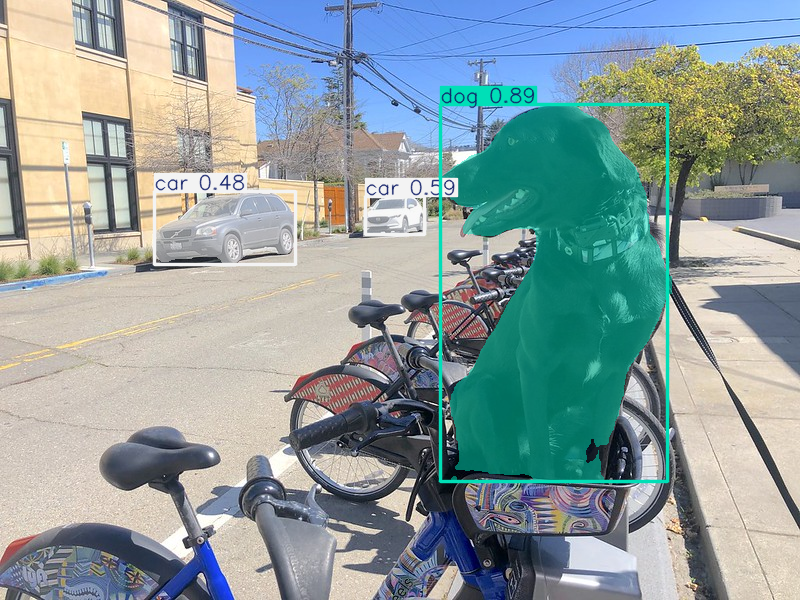

In [6]:
# Define the classes you want to detect
CLASSES = ["person", "bicycle", "car", "dog", "cat", "bus", "truck", "traffic light", "backpack", "handbag"]
model.set_classes(CLASSES)

# Run PyTorch inference with text prompts
from PIL import Image

results = model.predict(IMAGE_PATH)
Image.fromarray(results[0].plot()[:, :, ::-1])

The results include both bounding boxes and instance segmentation masks. Let's try with different, more specific classes:


image 1/1 /home/maleksandr/test_notebooks/yolov26/openvino_notebooks/notebooks/yolov26-optimization/data/coco_bike.jpg: 480x640 1 parked vehicle, 3 telegraph poles, 1 storage box, 72.1ms
Speed: 1.5ms preprocess, 72.1ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)


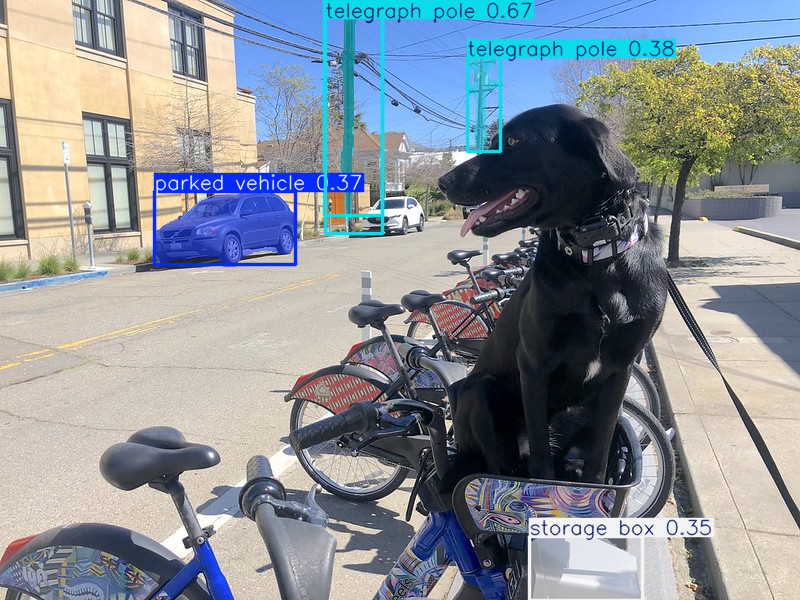

In [7]:
# Detect more specific or unusual classes — no retraining needed!
model.set_classes(["parked vehicle", "telegraph pole", "storage box"])

results = model.predict(IMAGE_PATH)
Image.fromarray(results[0].plot()[:, :, ::-1])

## Prompt-Free Detection
[back to top ⬆️](#Table-of-contents:)

YOLOE-26 also supports **prompt-free** mode using dedicated `-pf` model variants. These models use the **Lazy Region-Prompt Contrast (LRPC)** module with an internal vocabulary of 1200+ categories (from LVIS and Objects365), detecting objects without any external prompts.

This is ideal for general-purpose object discovery and cataloging.


image 1/1 /home/maleksandr/test_notebooks/yolov26/openvino_notebooks/notebooks/yolov26-optimization/data/coco_bike.jpg: 480x640 1 apartment, 1 belt, 1 car, 1 dog, 1 eucalyptus tree, 1 head, 1 moped, 1 motorcycle, 2 seats, 1 storage box, 1 suv, 3 telegraph poles, 72.6ms
Speed: 1.6ms preprocess, 72.6ms inference, 3.9ms postprocess per image at shape (1, 3, 480, 640)


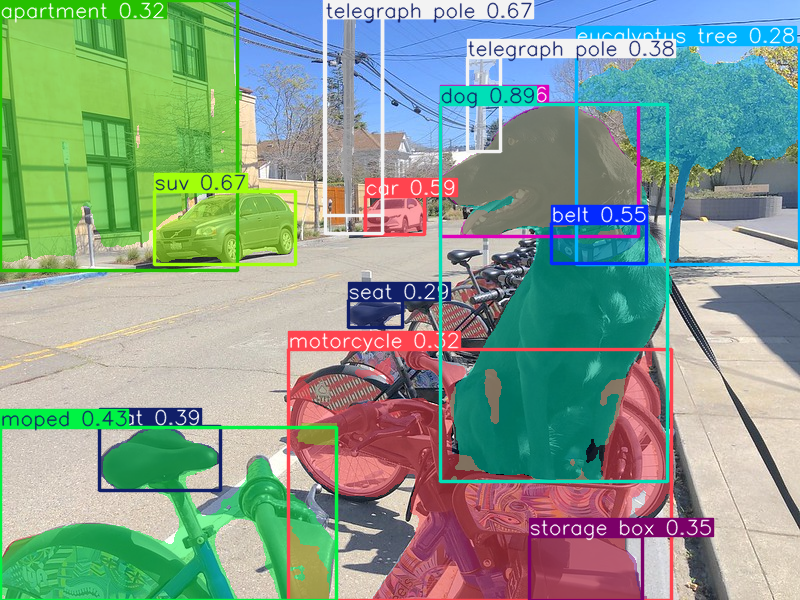

In [8]:
# Map the text/visual model to corresponding prompt-free model
pf_model_name = MODEL_NAME.replace("-seg", "-seg-pf")

pf_model = YOLOE(f"{pf_model_name}.pt")

# No set_classes needed — detects from 1200+ built-in categories
results_pf = pf_model.predict(IMAGE_PATH)
Image.fromarray(results_pf[0].plot()[:, :, ::-1])

## Convert to OpenVINO IR
[back to top ⬆️](#Table-of-contents:)

Ultralytics provides an API for exporting YOLOE-26 models to OpenVINO IR format. 

> **Important:** For text-prompted models, you must call `model.set_classes()` **before** exporting. The class vocabulary is baked into the exported model. For prompt-free models, no class setting is needed.

In [ ]:
# Export text-prompted model with specific classes
# Define the classes you want to detect in the deployed model
CLASSES = ["person", "bicycle", "car", "dog", "cat", "bus", "truck", "traffic light", "backpack", "handbag"]
model.set_classes(CLASSES)

ov_model_path = Path(f"{MODEL_NAME}_openvino_model/{MODEL_NAME}.xml")
if not ov_model_path.exists():
    model.export(format="openvino", dynamic=False, half=True, end2end=True)

### Export Prompt-Free Model
[back to top ⬆️](#Table-of-contents:)

We can also export the prompt-free model to OpenVINO IR. This model uses its built-in vocabulary of 1200+ categories and does not require any text or visual prompts.

In [ ]:
pf_ov_model_path = Path(f"{pf_model_name}_openvino_model/{pf_model_name}.xml")
if not pf_ov_model_path.exists():
    pf_model.export(format="openvino", dynamic=False, half=True)

### Select inference device
[back to top ⬆️](#Table-of-contents:)

Select device from dropdown list for running inference using OpenVINO.

In [11]:
device = device_widget()

device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

### Run OpenVINO Inference
[back to top ⬆️](#Table-of-contents:)

We can reuse the Ultralytics model pipeline by loading the exported OpenVINO model and specifying an Intel device.

Loading yoloe-26s-seg_openvino_model for OpenVINO inference...
WARNING ⚠️ OpenVINO device 'AUTO' not available. Using 'AUTO' instead.
Using OpenVINO LATENCY mode for batch=1 inference on CPU...

image 1/1 /home/maleksandr/test_notebooks/yolov26/openvino_notebooks/notebooks/yolov26-optimization/data/coco_bike.jpg: 640x640 2 bicycles, 2 cars, 1 dog, 42.2ms
Speed: 7.9ms preprocess, 42.2ms inference, 4.5ms postprocess per image at shape (1, 3, 640, 640)


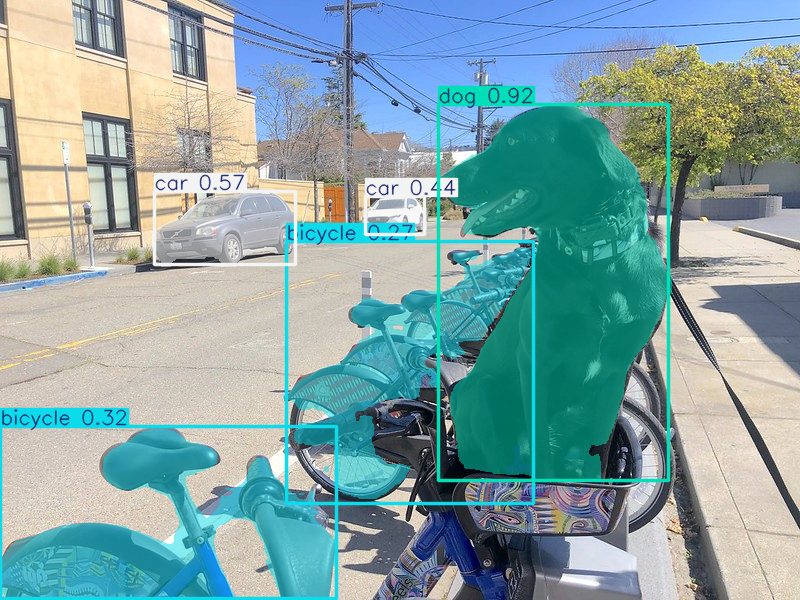

In [12]:
ov_model = YOLOE(ov_model_path.parent, task="segment")

res = ov_model(IMAGE_PATH, device=f"intel:{device.value.lower()}")
Image.fromarray(res[0].plot()[:, :, ::-1])

### Run Prompt-Free OpenVINO Inference
[back to top ⬆️](#Table-of-contents:)

Let's also verify the prompt-free model works correctly with OpenVINO. This model detects objects from its built-in 1200+ category vocabulary without any text or visual prompts.

Loading yoloe-26s-seg-pf_openvino_model for OpenVINO inference...
WARNING ⚠️ OpenVINO device 'AUTO' not available. Using 'AUTO' instead.
Using OpenVINO LATENCY mode for batch=1 inference on CPU...

image 1/1 /home/maleksandr/test_notebooks/yolov26/openvino_notebooks/notebooks/yolov26-optimization/data/coco_bike.jpg: 640x640 1 apartment, 1 belt, 1 bicycle, 1 car, 1 dog, 1 eucalyptus tree, 1 head, 1 moped, 2 seats, 1 suv, 3 telegraph poles, 107.5ms
Speed: 3.2ms preprocess, 107.5ms inference, 4.5ms postprocess per image at shape (1, 3, 640, 640)


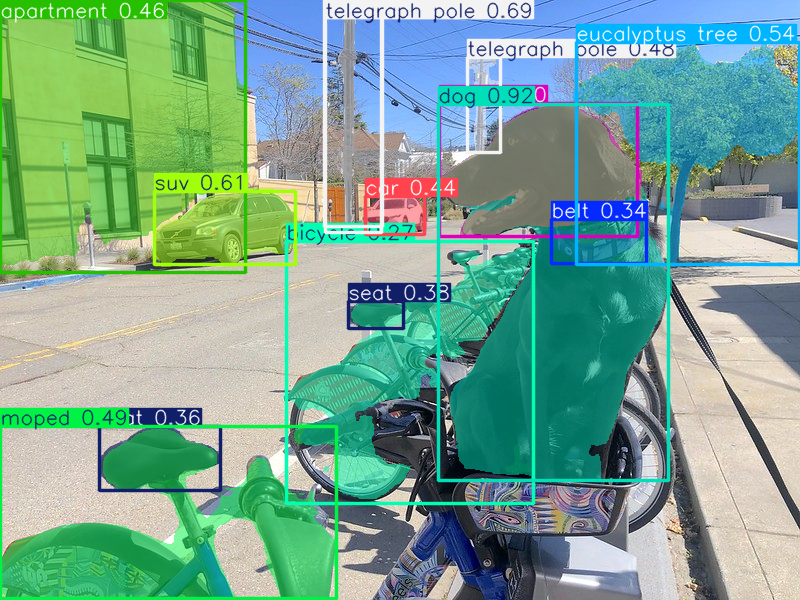

In [13]:
pf_ov_model = YOLOE(pf_ov_model_path.parent, task="segment")

res_pf = pf_ov_model(IMAGE_PATH, device=f"intel:{device.value.lower()}")
Image.fromarray(res_pf[0].plot()[:, :, ::-1])

## Optimize with NNCF Quantization
[back to top ⬆️](#Table-of-contents:)

[NNCF](https://github.com/openvinotoolkit/nncf) provides post-training quantization to optimize model inference speed. We use 8-bit quantization with the `MIXED` preset (symmetric weights + asymmetric activations).

The optimization process:
1. Create a calibration dataset.
2. Run `nncf.quantize` for an optimized model.
3. Save the INT8 OpenVINO IR model.

In [14]:
int8_model_path = Path(f"{MODEL_NAME}_openvino_model_int8/{MODEL_NAME}.xml")

to_quantize = quantization_widget()

to_quantize

Checkbox(value=True, description='Quantization')

In [15]:
if not Path("skip_kernel_extension.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/skip_kernel_extension.py",
    )
    open("skip_kernel_extension.py", "w").write(r.text)

%load_ext skip_kernel_extension

In [16]:
%%skip not $to_quantize.value

import nncf
import numpy as np
import openvino as ov
from zipfile import ZipFile

from notebook_utils import use_local_ultralytics_datasets


if not int8_model_path.exists():
    DATA_URL = "https://ultralytics.com/assets/coco128.zip"

    OUT_DIR = use_local_ultralytics_datasets()
    DATA_PATH = OUT_DIR / "coco128.zip"

    if not (OUT_DIR / "coco128").exists():
        download_file(DATA_URL, DATA_PATH.name, DATA_PATH.parent)
        with ZipFile(DATA_PATH, "r") as zip_ref:
            zip_ref.extractall(OUT_DIR)

    image_files = list((OUT_DIR / "coco128" / "images" / "train2017").glob("*.jpg"))

    core = ov.Core()
    ov_ir_model = core.read_model(ov_model_path)

    from ultralytics.data.augment import LetterBox
    import cv2

    letterbox = LetterBox(auto=False)

    def transform_fn(image_path):
        img = cv2.imread(str(image_path))
        img = letterbox(image=img)
        img = img.transpose(2, 0, 1)  # HWC to CHW
        img = img[::-1]  # BGR to RGB
        img = np.ascontiguousarray(img, dtype=np.float32) / 255.0
        return np.expand_dims(img, 0)

    quantization_dataset = nncf.Dataset(image_files, transform_fn)

In [ ]:
%%skip not $to_quantize.value

import shutil

if not int8_model_path.exists():
    quantized_model = nncf.quantize(
        ov_ir_model,
        quantization_dataset,
        preset=nncf.QuantizationPreset.MIXED,
        fast_bias_correction=False,
        ignored_scope=nncf.IgnoredScope(patterns=[".*one2one.*"]),
    )
    print(f"Quantized model will be saved to {int8_model_path}")
    ov.save_model(quantized_model, str(int8_model_path))
    shutil.copy(ov_model_path.parent / "metadata.yaml", int8_model_path.parent / "metadata.yaml")

### Validate Quantized Model
[back to top ⬆️](#Table-of-contents:)

Let's verify the quantized model produces correct results on the test image.

Loading yoloe-26s-seg_openvino_model_int8 for OpenVINO inference...
WARNING ⚠️ OpenVINO device 'AUTO' not available. Using 'AUTO' instead.
Using OpenVINO LATENCY mode for batch=1 inference on CPU...

image 1/1 /home/maleksandr/test_notebooks/yolov26/openvino_notebooks/notebooks/yolov26-optimization/data/coco_bike.jpg: 640x640 2 bicycles, 2 cars, 1 dog, 31.5ms
Speed: 6.3ms preprocess, 31.5ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 640)


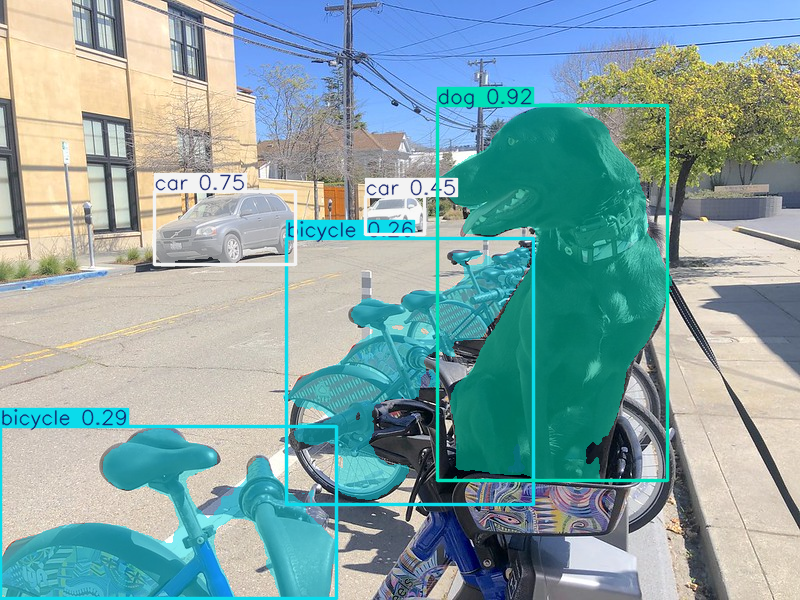

In [18]:
%%skip not $to_quantize.value

int8_ov_model = YOLOE(int8_model_path.parent, task="segment")

res = int8_ov_model(IMAGE_PATH, device=f"intel:{device.value.lower()}")
display(Image.fromarray(res[0].plot()[:, :, ::-1]))

## Compare Performance
[back to top ⬆️](#Table-of-contents:)

Use the OpenVINO [Benchmark Tool](https://docs.openvino.ai/2026/learn-openvino/openvino-samples/benchmark-tool.html) to measure the inference performance of the FP16 and INT8 models.

> **Note**: For more accurate performance, it is recommended to run `benchmark_app` in a terminal/command prompt after closing other applications.

In [19]:
device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

In [20]:
# Inference FP16 model (OpenVINO IR)
!benchmark_app -m $ov_model_path -d $device.value -api async -shape "[1,3,640,640]" -t 15

[Step 1/11] Parsing and validating input arguments
[ INFO ] Parsing input parameters
[Step 2/11] Loading OpenVINO Runtime
[ INFO ] OpenVINO:
[ INFO ] Build ................................. 2026.0.0-20965-c6d6a13a886-releases/2026/0
[ INFO ] 
[ INFO ] Device info:
[ INFO ] AUTO
[ INFO ] Build ................................. 2026.0.0-20965-c6d6a13a886-releases/2026/0
[ INFO ] 
[ INFO ] 
[Step 3/11] Setting device configuration
[ WARNING ] Performance hint was not explicitly specified in command line or config file. Device(AUTO) performance hint will be set to PerformanceMode.THROUGHPUT.
[Step 4/11] Reading model files
[ INFO ] Loading model files
[ INFO ] Read model took 17.58 ms
[ INFO ] Original model I/O parameters:
[ INFO ] Model inputs:
[ INFO ]     x (node: x) : f32 / [...] / [1,3,640,640]
[ INFO ] Model outputs:
[ INFO ]     ***NO_NAME*** (node: __module.model.23/aten::cat/Concat_5) : f32 / [...] / [1,300,38]
[ INFO ]     input (node: __module.model.23.cv5.2.1.act/aten::silu_/S

In [21]:
if int8_model_path.exists():
    # Inference INT8 model (OpenVINO IR)
    !benchmark_app -m $int8_model_path -d $device.value -api async -shape "[1,3,640,640]" -t 15

[Step 1/11] Parsing and validating input arguments
[ INFO ] Parsing input parameters
[Step 2/11] Loading OpenVINO Runtime
[ INFO ] OpenVINO:
[ INFO ] Build ................................. 2026.0.0-20965-c6d6a13a886-releases/2026/0
[ INFO ] 
[ INFO ] Device info:
[ INFO ] AUTO
[ INFO ] Build ................................. 2026.0.0-20965-c6d6a13a886-releases/2026/0
[ INFO ] 
[ INFO ] 
[Step 3/11] Setting device configuration
[ WARNING ] Performance hint was not explicitly specified in command line or config file. Device(AUTO) performance hint will be set to PerformanceMode.THROUGHPUT.
[Step 4/11] Reading model files
[ INFO ] Loading model files
[ INFO ] Read model took 28.09 ms
[ INFO ] Original model I/O parameters:
[ INFO ] Model inputs:
[ INFO ]     x (node: x) : f32 / [...] / [1,3,640,640]
[ INFO ] Model outputs:
[ INFO ]     ***NO_NAME*** (node: __module.model.23/aten::cat/Concat_5) : f32 / [...] / [1,300,38]
[ INFO ]     input (node: __module.model.23.cv5.2.1.act/aten::silu_/S

## Interactive Demo
[back to top ⬆️](#Table-of-contents:)

The following code runs YOLOE-26 inference on a video. You can choose between the **prompt-free** model (1200+ categories, no setup needed — the main showcase of YOLOE) and the **text-prompted** model (custom class vocabulary).

In [22]:
import collections
import time
from IPython import display
import cv2
import numpy as np


def run_yoloe_demo(
    source=0,
    flip=False,
    use_popup=False,
    skip_first_frames=0,
    model=ov_model,
    device=device.value,
    video_width: int = None,
):
    player = None

    try:
        player = VideoPlayer(source=source, flip=flip, fps=30, skip_first_frames=skip_first_frames)
        player.start()
        if use_popup:
            title = "Press ESC to Exit"
            cv2.namedWindow(winname=title, flags=cv2.WINDOW_GUI_NORMAL | cv2.WINDOW_AUTOSIZE)

        processing_times = collections.deque()
        while True:
            frame = player.next()
            if frame is None:
                print("Source ended")
                break

            if video_width:
                scale = video_width / max(frame.shape)
                frame = cv2.resize(
                    src=frame,
                    dsize=None,
                    fx=scale,
                    fy=scale,
                    interpolation=cv2.INTER_AREA,
                )

            input_image = np.array(frame)

            start_time = time.time()
            detections = model(input_image, verbose=False, device=f"intel:{device.lower()}")
            stop_time = time.time()
            frame = detections[0].plot()

            processing_times.append(stop_time - start_time)
            if len(processing_times) > 200:
                processing_times.popleft()

            _, f_width = frame.shape[:2]
            processing_time = np.mean(processing_times) * 1000
            fps = 1000 / processing_time
            cv2.putText(
                img=frame,
                text=f"Inference time: {processing_time:.1f}ms ({fps:.1f} FPS)",
                org=(20, 40),
                fontFace=cv2.FONT_HERSHEY_COMPLEX,
                fontScale=f_width / 1000,
                color=(0, 0, 255),
                thickness=1,
                lineType=cv2.LINE_AA,
            )
            if use_popup:
                cv2.imshow(winname=title, mat=frame)
                key = cv2.waitKey(1)
                if key == 27:
                    break
            else:
                _, encoded_img = cv2.imencode(ext=".jpg", img=frame, params=[cv2.IMWRITE_JPEG_QUALITY, 100])
                i = display.Image(data=encoded_img)
                display.clear_output(wait=True)
                display.display(i)
    except KeyboardInterrupt:
        print("Interrupted")
    except RuntimeError as e:
        print(e)
    finally:
        if player is not None:
            player.stop()
        if use_popup:
            cv2.destroyAllWindows()

>**NOTE**: To use this notebook with a webcam, you need to run the notebook on a computer with a webcam. If you run the notebook on a remote server, the webcam will not work. By default, the lower cell will run model inference on a video file. If you want to try live inference on your webcam set `WEBCAM_INFERENCE = True`

In [23]:
WEBCAM_INFERENCE = False

if WEBCAM_INFERENCE:
    VIDEO_SOURCE = 0  # Webcam
else:
    VIDEO_SOURCE = "people.mp4"
    if not Path(VIDEO_SOURCE).exists():
        download_file(
            "https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/video/people.mp4",
            "people.mp4",
        )

In [24]:
device

Dropdown(description='Device:', index=1, options=('CPU', 'AUTO'), value='AUTO')

In [25]:
demo_model_selector = widgets.Dropdown(
    options={"Prompt-Free (1200+ categories)": pf_ov_model, "Text-Prompted (custom classes)": ov_model},
    description="Demo model:",
    style={"description_width": "initial"},
)
demo_model_selector

Dropdown(description='Demo model:', options={'Prompt-Free (1200+ categories)': YOLOE(), 'Text-Prompted (custom…

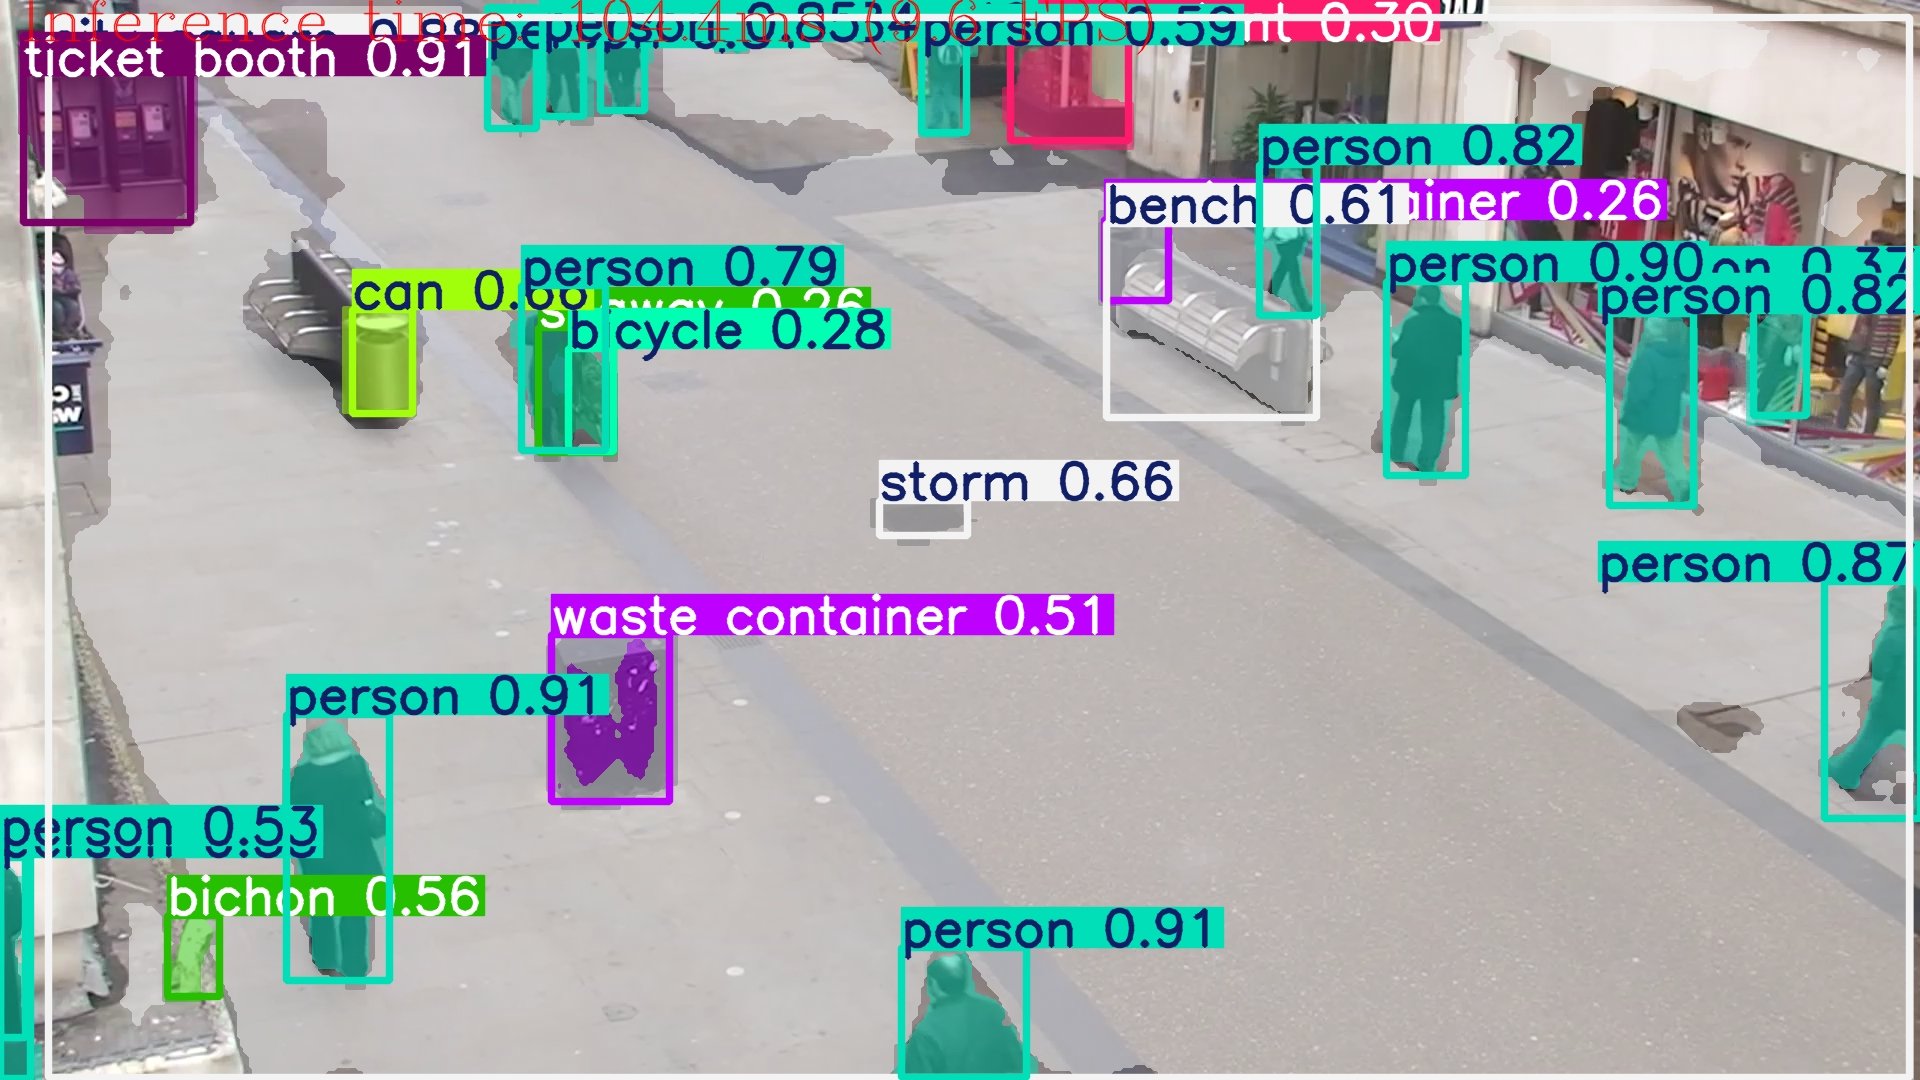

Source ended


In [26]:
run_yoloe_demo(
    source=VIDEO_SOURCE,
    flip=True,
    use_popup=False,
    model=demo_model_selector.value,
    device=device.value,
)